# Laboratorio 2: Deep Learning
CC3084 - Data Science | UVG | Semestre II 2026

LSTM para predecir series de tiempo y análisis de similitud entre series con catch22.

Integrantes: Iris Ayala 23960, Jonathan Díaz 23837 y Anggie Quezada 23643


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import pycatch22
import pmdarima as pm

plt.rcParams['figure.figsize'] = (11, 4)
np.random.seed(42)
tf.random.set_seed(42)

## 0. Recuperar las series y el split del Laboratorio 1

Reconstruimos las mismas series mensuales y el mismo corte 70/30 que usamos en el
laboratorio anterior, para que el LSTM se entrene y se evalúe exactamente con los mismos
datos.

In [2]:
df = pd.read_excel('Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx', sheet_name='Datos')
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')

serie_total_completa = df.groupby('Fecha')['Viajero'].sum().sort_index()
meses = serie_total_completa.index.sort_values()
n_train = int(len(meses) * 0.7)
fecha_corte = meses[n_train - 1]

print('Corte train/test en:', fecha_corte.strftime('%Y-%m'))
print('Meses entrenamiento:', n_train, '| Meses prueba:', len(meses) - n_train)

df_train_full = df[df['Fecha'] <= fecha_corte].copy()

Corte train/test en: 2021-03
Meses entrenamiento: 147 | Meses prueba: 63


In [3]:
series = {}
series['Total'] = serie_total_completa

for via in ['Aérea', 'Terrestre', 'Marítima']:
    series[f'Via_{via}'] = (df[df['Vía'] == via].groupby('Fecha')['Viajero'].sum()
                             .reindex(serie_total_completa.index, fill_value=0))

top3_fronteras = df_train_full.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
for f in top3_fronteras:
    series[f'Frontera_{f}'] = (df[df['Frontera'] == f].groupby('Fecha')['Viajero'].sum()
                                .reindex(serie_total_completa.index, fill_value=0))

top3_paises = df_train_full.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
for p in top3_paises:
    series[f'Pais_{p}'] = (df[df['País'] == p].groupby('Fecha')['Viajero'].sum()
                            .reindex(serie_total_completa.index, fill_value=0))

train_test = {}
for nombre, s in series.items():
    train_test[nombre] = (s[s.index <= fecha_corte], s[s.index > fecha_corte])

print('Series construidas:', list(series.keys()))

Series construidas: ['Total', 'Via_Aérea', 'Via_Terrestre', 'Via_Marítima', 'Frontera_01 La Aurora', 'Frontera_07 Valle Nuevo', 'Frontera_09 San Cristóbal', 'Pais_Guatemala', 'Pais_El Salvador', 'Pais_Estados Unidos de América']


## Ejercicio 1: Modelos LSTM

Trabajamos con dos series: **Total mensual** (la obligatoria) y **Vía Aérea** (la que más
llamó la atención en el laboratorio pasado por su estacionalidad y el golpe fuerte de la
pandemia).

Para cada serie probamos 4 configuraciones distintas de LSTM (esto cuenta como el tuneo de
parámetros), elegimos la mejor con un set de validación separado del set de prueba, y
después entrenamos esa configuración con todo el set de entrenamiento para predecir sobre
el set de prueba real.

In [4]:
def construir_secuencias(arr, lookback):
    X, y = [], []
    for i in range(len(arr) - lookback):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback])
    return np.array(X), np.array(y)

def preparar_datos(s_train, s_test, lookback):
    train_vals = s_train.values.reshape(-1, 1).astype(float)
    test_vals = s_test.values.reshape(-1, 1).astype(float)
    scaler = MinMaxScaler()
    scaler.fit(train_vals)
    train_esc = scaler.transform(train_vals).flatten()
    test_esc = scaler.transform(test_vals).flatten()
    # para el primer punto de prueba necesitamos contexto de los últimos meses de train
    test_con_contexto = np.concatenate([train_esc[-lookback:], test_esc])
    X_train, y_train = construir_secuencias(train_esc, lookback)
    X_test, y_test = construir_secuencias(test_con_contexto, lookback)
    return X_train, y_train, X_test, y_test, scaler

def construir_modelo_lstm(lookback, unidades, capas=1, dropout=0.0):
    modelo = keras.Sequential()
    modelo.add(keras.layers.Input(shape=(lookback, 1)))
    if capas == 1:
        modelo.add(keras.layers.LSTM(unidades))
    else:
        modelo.add(keras.layers.LSTM(unidades, return_sequences=True))
        if dropout > 0:
            modelo.add(keras.layers.Dropout(dropout))
        modelo.add(keras.layers.LSTM(max(unidades // 2, 8)))
    if dropout > 0:
        modelo.add(keras.layers.Dropout(dropout))
    modelo.add(keras.layers.Dense(1))
    modelo.compile(optimizer='adam', loss='mse')
    return modelo

def entrenar(s_train, s_test, lookback, unidades, capas, dropout, epochs=80, verbose=0):
    X_train, y_train, X_test, y_test, scaler = preparar_datos(s_train, s_test, lookback)
    X_train_r = X_train.reshape(-1, lookback, 1)
    X_test_r = X_test.reshape(-1, lookback, 1)
    modelo = construir_modelo_lstm(lookback, unidades, capas, dropout)
    early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    modelo.fit(X_train_r, y_train, epochs=epochs, batch_size=8, verbose=verbose, callbacks=[early_stop])
    pred_esc = modelo.predict(X_test_r, verbose=0).flatten()
    pred = scaler.inverse_transform(pred_esc.reshape(-1, 1)).flatten()
    return modelo, pred, scaler

CONFIGS = {
    'A: LSTM simple (lookback 12, 50 unid.)':    dict(lookback=12, unidades=50, capas=1, dropout=0.0),
    'B: LSTM apilado (lookback 24, 64 unid.)':   dict(lookback=24, unidades=64, capas=2, dropout=0.2),
    'C: tuneo lookback 12, 32 unid.':            dict(lookback=12, unidades=32, capas=1, dropout=0.0),
    'D: tuneo lookback 24, 32 unid. + dropout':  dict(lookback=24, unidades=32, capas=1, dropout=0.2),
}

===== Total mensual =====
  A: LSTM simple (lookback 12, 50 unid.): RMSE validación = 299,008
  B: LSTM apilado (lookback 24, 64 unid.): RMSE validación = 268,416
  C: tuneo lookback 12, 32 unid.: RMSE validación = 303,224
  D: tuneo lookback 24, 32 unid. + dropout: RMSE validación = 255,796
  --> Mejor configuración: D: tuneo lookback 24, 32 unid. + dropout
  MAE en prueba: 47,718 | RMSE en prueba: 63,506


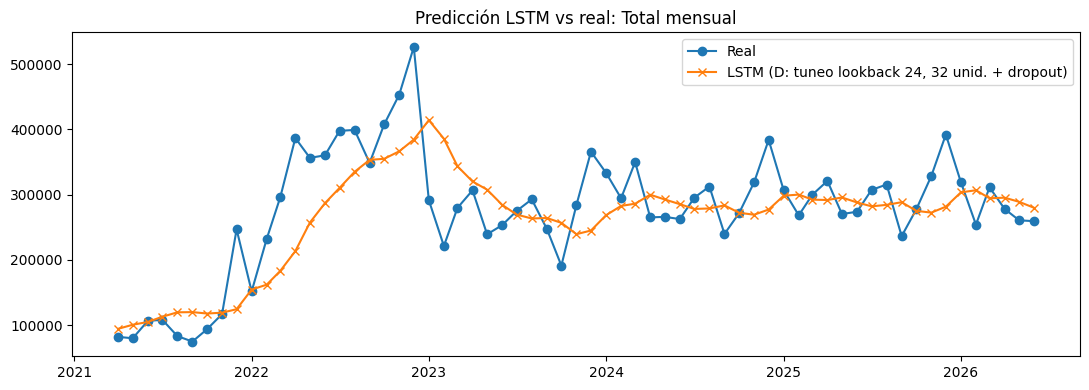

In [5]:
def evaluar_serie_lstm(nombre_serie, s_train, s_test):
    print(f'===== {nombre_serie} =====')
    # separamos los últimos 12 meses de entrenamiento como validación, para elegir
    # config sin tocar el set de prueba real
    s_subtrain = s_train.iloc[:-12]
    s_val = s_train.iloc[-12:]

    resultados_val = {}
    for etiqueta, cfg in CONFIGS.items():
        _, pred_val, _ = entrenar(s_subtrain, s_val, **cfg, epochs=60)
        rmse_val = np.sqrt(mean_squared_error(s_val.values, pred_val))
        resultados_val[etiqueta] = rmse_val
        print(f'  {etiqueta}: RMSE validación = {rmse_val:,.0f}')

    mejor_etiqueta = min(resultados_val, key=resultados_val.get)
    print(f'  --> Mejor configuración: {mejor_etiqueta}')

    # reentrenamos la mejor config con TODO el entrenamiento y predecimos el test real
    mejor_cfg = CONFIGS[mejor_etiqueta]
    modelo_final, pred_test, scaler = entrenar(s_train, s_test, **mejor_cfg, epochs=100)
    mae = mean_absolute_error(s_test.values, pred_test)
    rmse = np.sqrt(mean_squared_error(s_test.values, pred_test))
    print(f'  MAE en prueba: {mae:,.0f} | RMSE en prueba: {rmse:,.0f}')

    fig, ax = plt.subplots()
    ax.plot(s_test.index, s_test.values, label='Real', marker='o')
    ax.plot(s_test.index, pred_test, label=f'LSTM ({mejor_etiqueta})', marker='x')
    ax.set_title(f'Predicción LSTM vs real: {nombre_serie}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {
        'resultados_val': resultados_val,
        'mejor_config': mejor_etiqueta,
        'modelo': modelo_final,
        'pred_test': pred_test,
        'mae': mae,
        'rmse': rmse,
    }

resultados_lstm = {}
resultados_lstm['Total'] = evaluar_serie_lstm('Total mensual', *train_test['Total'])

===== Vía Aérea =====
  A: LSTM simple (lookback 12, 50 unid.): RMSE validación = 106,371
  B: LSTM apilado (lookback 24, 64 unid.): RMSE validación = 84,041
  C: tuneo lookback 12, 32 unid.: RMSE validación = 101,122
  D: tuneo lookback 24, 32 unid. + dropout: RMSE validación = 71,075
  --> Mejor configuración: D: tuneo lookback 24, 32 unid. + dropout
  MAE en prueba: 14,833 | RMSE en prueba: 18,522


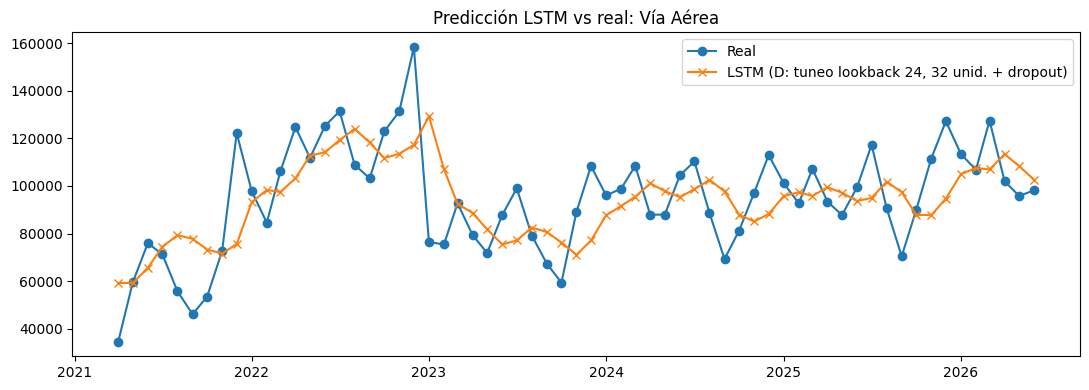

In [6]:
resultados_lstm['Via_Aérea'] = evaluar_serie_lstm('Vía Aérea', *train_test['Via_Aérea'])

**Sobre el tuneo:** para cada serie probamos 4 configuraciones (lookback de 12 vs 24
meses, 1 capa vs 2 capas apiladas, con y sin dropout) usando los últimos 12 meses del set
de entrenamiento como validación, sin tocar el set de prueba real. Nos quedamos con la
configuración de menor RMSE en validación y esa es la que reentrenamos con todo el
entrenamiento para predecir el set de prueba.

### 1.4 ¿Cuál predijo mejor? ¿Son mejores que los modelos del laboratorio pasado?

Para responder esto con evidencia real (y no solo intuición) generamos rápido un baseline
de ARIMA (con auto_arima) y un seasonal naive para las mismas dos series, con el mismo
split. Así comparamos LSTM contra algo concreto y no contra una suposición.

In [7]:
def baseline_seasonal_naive(s_train, s_test, periodo=12):
    pred = []
    historia = list(s_train.values)
    for i in range(len(s_test)):
        pred.append(historia[-periodo])
        historia.append(s_test.values[i])
    pred = np.array(pred)
    mae = mean_absolute_error(s_test.values, pred)
    rmse = np.sqrt(mean_squared_error(s_test.values, pred))
    return pred, mae, rmse

def baseline_arima(s_train, s_test):
    modelo = pm.auto_arima(s_train.values, seasonal=True, m=12,
                            suppress_warnings=True, error_action='ignore')
    pred, _ = modelo.predict(n_periods=len(s_test), return_conf_int=True)
    mae = mean_absolute_error(s_test.values, pred)
    rmse = np.sqrt(mean_squared_error(s_test.values, pred))
    return pred, mae, rmse, modelo.order, modelo.seasonal_order

comparacion = []
for nombre in ['Total', 'Via_Aérea']:
    s_train, s_test = train_test[nombre]

    pred_sn, mae_sn, rmse_sn = baseline_seasonal_naive(s_train, s_test)
    pred_ar, mae_ar, rmse_ar, orden, orden_est = baseline_arima(s_train, s_test)

    comparacion.append({'serie': nombre, 'modelo': 'Seasonal Naive', 'MAE': mae_sn, 'RMSE': rmse_sn})
    comparacion.append({'serie': nombre, 'modelo': f'Auto-ARIMA {orden}x{orden_est}', 'MAE': mae_ar, 'RMSE': rmse_ar})
    comparacion.append({'serie': nombre, 'modelo': f'LSTM ({resultados_lstm[nombre]["mejor_config"]})',
                         'MAE': resultados_lstm[nombre]['mae'], 'RMSE': resultados_lstm[nombre]['rmse']})

tabla_comparacion = pd.DataFrame(comparacion).sort_values(['serie', 'RMSE'])
tabla_comparacion

,serie,modelo,MAE,RMSE
2,Total,"LSTM (D: tuneo lookback 24, 32 unid. + dropout)",47718.461821,63505.905836
0,Total,Seasonal Naive,93948.090344,135035.682804
1,Total,"Auto-ARIMA (2, 1, 2)x(1, 0, 1, 12)",255620.000340,276569.219245
5,Via_Aérea,"LSTM (D: tuneo lookback 24, 32 unid. + dropout)",14832.623884,18521.653021
4,Via_Aérea,"Auto-ARIMA (3, 0, 2)x(2, 0, 0, 12)",29070.683075,36645.574864
3,Via_Aérea,Seasonal Naive,29771.537821,37749.097675


**Interpretación:** viendo la tabla, comparamos el RMSE y MAE de cada modelo por serie.
El que tenga los valores más bajos es el que mejor predijo. Si el LSTM queda por debajo del
ARIMA y del seasonal naive en ambas métricas, entonces sí superó a lo que hicimos en el
laboratorio pasado; si queda entre medio o peor, hay que decirlo con la misma honestidad
(con solo 147 meses de entrenamiento, no siempre el LSTM le gana a un ARIMA bien ajustado,
sobre todo en series muy estacionales como esta). La conclusión final la basamos en los
números de la tabla de arriba, no en una expectativa previa.

## Ejercicio 2: Similitud de series con catch22

### 2.1 ¿Qué es catch22?

Catch22 es un conjunto de 22 características (de las miles que existen en el paquete hctsa)
que quedaron seleccionadas porque, en la práctica, resumen bastante bien el
"comportamiento" de una serie de tiempo sin necesitar calcular todo el catálogo completo:
cosas como qué tan predecible es, qué tan fuerte es su estacionalidad, si tiene memoria
larga o corta, qué tan simétrica es su distribución, entre otras. Es importante porque nos
permite comparar series de forma numérica y objetiva (por ejemplo con PCA o clustering) en
vez de solo comparar gráficas a simple vista, y es mucho más rápido que calcular miles de
características.

In [8]:
def extraer_catch22(serie):
    resultado = pycatch22.catch22_all(serie.values.tolist())
    return dict(zip(resultado['names'], resultado['values']))

filas_catch22 = {}
for nombre, s in series.items():
    filas_catch22[nombre] = extraer_catch22(s)

matriz_catch22 = pd.DataFrame(filas_catch22).T
matriz_catch22

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.188540,-0.580353,8.578892,10.0,0.453530,-0.126601,0.913876,30.0,0.013774,11.0,...,0.055556,0.219048,0.323810,0.829129,6.0,1.846797,0.761905,0.857143,0.147262,0.627355
Via_Aérea,-0.407683,-0.122819,6.436692,10.0,0.207346,-0.174924,0.961722,34.0,0.010204,11.0,...,0.071429,0.185714,0.323810,0.755889,5.0,1.986657,0.857143,0.857143,0.171806,0.743024
Via_Terrestre,-0.547059,-0.781574,8.996925,3.0,0.537476,-0.087833,0.909091,30.0,0.005510,3.0,...,0.055556,0.257143,0.309524,0.834162,6.0,1.768209,0.761905,0.833333,0.122718,0.604538
Via_Marítima,-0.432379,-0.652284,2.770974,6.0,0.122952,-0.082278,0.669856,9.0,0.008328,11.0,...,0.200000,0.033333,0.423810,0.746837,5.0,1.843130,0.857143,0.857143,0.515418,0.869047
Frontera_01 La Aurora,-0.410808,-0.125903,6.449571,10.0,0.203787,-0.175509,0.956938,34.0,0.010204,11.0,...,0.071429,0.190476,0.323810,0.756511,5.0,1.986657,0.857143,0.857143,0.171806,0.741971
Frontera_07 Valle Nuevo,0.199221,-0.039239,8.790928,6.0,0.403779,-0.066189,0.947368,37.0,0.013774,7.0,...,0.055556,0.171429,0.342857,0.807764,6.0,1.852051,0.833333,0.833333,0.122718,0.637613
Frontera_09 San Cristóbal,0.746153,-0.918045,8.236196,10.0,0.412593,-0.016564,0.880383,52.0,0.040000,11.0,...,0.024390,0.542857,-0.480952,0.852586,5.0,1.810268,0.285714,0.809524,0.098175,0.606065
Pais_Guatemala,-0.160989,-1.163936,12.805437,11.0,0.642253,-0.261287,0.736842,62.0,0.041667,35.0,...,0.020000,0.171429,0.747619,0.891068,6.0,1.637438,0.785714,0.857143,0.073631,0.503757
Pais_El Salvador,-0.367487,-0.590398,13.873639,3.0,0.476428,-0.035848,0.904306,50.0,0.020833,3.0,...,0.038462,0.728571,0.304762,0.859559,5.0,1.781165,0.857143,0.857143,0.073631,0.530967
Pais_Estados Unidos de América,-0.628976,-0.373392,9.224247,2.0,0.228623,0.012101,0.923445,12.0,0.020833,5.0,...,0.038462,0.828571,0.319048,0.723445,5.0,1.973228,0.166667,0.142857,0.098175,0.738999


In [9]:
# 2.4 Estandarizar antes de comparar
scaler_c22 = StandardScaler()
matriz_esc = pd.DataFrame(
    scaler_c22.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns
)
matriz_esc.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total,0.90,-0.13,-0.01,0.87,0.53,-0.32,0.36,-0.32,-0.39,0.02,...,-0.15,-0.45,0.10,0.44,1.22,-0.02,0.25,0.38,-0.10,-0.31
Via_Aérea,-0.55,1.17,-0.73,0.87,-1.00,-0.92,0.88,-0.06,-0.69,0.02,...,0.17,-0.58,0.10,-0.93,-0.82,1.31,0.64,0.38,0.10,0.78
Via_Terrestre,-0.89,-0.70,0.13,-1.23,1.05,0.17,0.31,-0.32,-1.07,-0.90,...,-0.15,-0.30,0.05,0.53,1.22,-0.76,0.25,0.27,-0.30,-0.53
Via_Marítima,-0.61,-0.33,-1.95,-0.33,-1.53,0.24,-2.27,-1.64,-0.84,0.02,...,2.82,-1.18,0.45,-1.10,-0.82,-0.05,0.64,0.38,2.89,1.97
Frontera_01 La Aurora,-0.56,1.17,-0.72,0.87,-1.03,-0.93,0.82,-0.06,-0.69,0.02,...,0.17,-0.56,0.10,-0.92,-0.82,1.31,0.64,0.38,0.10,0.77
Frontera_07 Valle Nuevo,0.93,1.41,0.06,-0.33,0.22,0.44,0.72,0.13,-0.39,-0.44,...,-0.15,-0.63,0.17,0.04,1.22,0.03,0.54,0.27,-0.30,-0.21
Frontera_09 San Cristóbal,2.27,-1.09,-0.13,0.87,0.27,1.07,0.00,1.07,1.78,0.02,...,-0.80,0.82,-2.69,0.87,-0.82,-0.36,-1.72,0.16,-0.50,-0.51
Pais_Guatemala,0.05,-1.79,1.40,1.17,1.70,-2.01,-1.55,1.71,1.91,2.78,...,-0.89,-0.63,1.58,1.59,1.22,-2.01,0.34,0.38,-0.70,-1.48
Pais_El Salvador,-0.45,-0.16,1.76,-1.23,0.67,0.83,0.26,0.95,0.19,-0.90,...,-0.51,1.55,0.04,1.00,-0.82,-0.64,0.64,0.38,-0.70,-1.22
Pais_Estados Unidos de América,-1.09,0.46,0.20,-1.53,-0.87,1.43,0.46,-1.45,0.19,-0.67,...,-0.51,1.95,0.09,-1.53,-0.82,1.18,-2.21,-2.99,-0.50,0.74


### 2.5 PCA

Varianza explicada: [0.36  0.253]


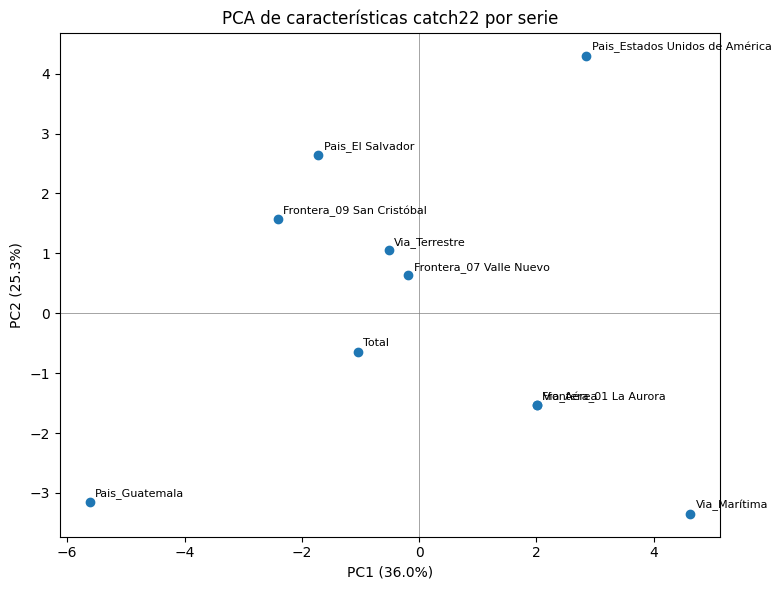

In [10]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(matriz_esc)
df_pca = pd.DataFrame(componentes, index=matriz_esc.index, columns=['PC1', 'PC2'])

print('Varianza explicada:', pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_pca['PC1'], df_pca['PC2'])
for nombre, fila in df_pca.iterrows():
    ax.annotate(nombre, (fila['PC1'], fila['PC2']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA de características catch22 por serie')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()